# Graph Schema Validation Report for OPFData

This notebook validates whether `power_graph_builder.py` produces a research-usable graph representation.
It checks structure consistency, dimensional consistency, type distributions, information preservation, and normalization behavior.


In [7]:
from pathlib import Path
from collections import Counter, defaultdict
import json

from power_graph_builder import (
    PowerGraphBuilder,
    NODE_FEAT_DIM, EDGE_FEAT_DIM,
    NODE_RAW_MAX, EDGE_RAW_MAX,
    SOL_NODE_DIM, SOL_EDGE_DIM,
)

DATA_ROOT = Path('power_demo_work/opfdata')
JSON_FILES = sorted(DATA_ROOT.rglob('*.json'))
assert JSON_FILES, f'No OPFData JSON files found in {DATA_ROOT}. Run `python download_dataset.py` from the repository root first.'

print(f'Found {len(JSON_FILES)} OPFData samples under {DATA_ROOT}')
print('First sample:', JSON_FILES[0])


Found 34 OPFData samples under power_demo_work/opfdata
First sample: power_demo_work/opfdata/dataset_release_1__pglib_opf_case14_ieee_0_extracted/gridopt-dataset-tmp/dataset_release_1/pglib_opf_case14_ieee/group_0/example_0.json


## 1) Raw OPFData structure sanity


In [8]:
sample_path = JSON_FILES[0]
sample = json.loads(sample_path.read_text(encoding='utf-8'))

print('Top-level keys:', list(sample.keys()))
print('grid.nodes keys:', list(sample['grid']['nodes'].keys()))
print('grid.edges keys:', list(sample['grid']['edges'].keys()))
print('solution.nodes keys:', list(sample.get('solution', {}).get('nodes', {}).keys()))
print('solution.edges keys:', list(sample.get('solution', {}).get('edges', {}).keys()))
print('metadata keys:', list(sample.get('metadata', {}).keys()))


Top-level keys: ['grid', 'solution', 'metadata']
grid.nodes keys: ['bus', 'generator', 'load', 'shunt']
grid.edges keys: ['ac_line', 'transformer', 'generator_link', 'load_link', 'shunt_link']
solution.nodes keys: ['bus', 'generator']
solution.edges keys: ['ac_line', 'transformer']
metadata keys: ['objective']


## 2) Transformed graph structure sanity (single sample)


In [9]:
builder = PowerGraphBuilder(normalize_features=False, include_solution=True, include_links=True)
g = builder.build_graph_from_json(sample_path)

if hasattr(g, 'x'):
    # PyG Data
    x = g.x.tolist()
    edge_index = g.edge_index.tolist()
    edge_attr = g.edge_attr.tolist()
    sol_node = g.sol_node.tolist()
    sol_edge = g.sol_edge.tolist()
    meta = g.meta
    node_type = g.node_type.tolist() if hasattr(g, 'node_type') else None
    edge_type = g.edge_type.tolist() if hasattr(g, 'edge_type') else None
else:
    x = g['x']
    edge_index = g['edge_index']
    edge_attr = g['edge_attr']
    sol_node = g['sol_node']
    sol_edge = g['sol_edge']
    meta = g['meta']
    node_type = g.get('node_type')
    edge_type = g.get('edge_type')

print('x shape:', (len(x), len(x[0]) if x else 0), 'expected last dim', NODE_FEAT_DIM)
print('edge_index shape:', (len(edge_index), len(edge_index[0]) if edge_index else 0))
print('edge_attr shape:', (len(edge_attr), len(edge_attr[0]) if edge_attr else 0), 'expected last dim', EDGE_FEAT_DIM)
print('sol_node shape:', (len(sol_node), len(sol_node[0]) if sol_node else 0), 'expected', SOL_NODE_DIM)
print('sol_edge shape:', (len(sol_edge), len(sol_edge[0]) if sol_edge else 0), 'expected', SOL_EDGE_DIM)
print('meta:', meta)
print('node_type present:', node_type is not None, '| edge_type present:', edge_type is not None)


x shape: (31, 15) expected last dim 15
edge_index shape: (2, 37)
edge_attr shape: (37, 16) expected last dim 16
sol_node shape: (31, 2) expected 2
sol_edge shape: (37, 4) expected 4
meta: {'source_file': 'power_demo_work/opfdata/dataset_release_1__pglib_opf_case14_ieee_0_extracted/gridopt-dataset-tmp/dataset_release_1/pglib_opf_case14_ieee/group_0/example_0.json', 'n_bus': 14, 'n_gen': 5, 'n_load': 11, 'n_shunt': 1, 'n_nodes': 31, 'n_edges': 37, 'node_type_counts': {'bus': 14, 'generator': 5, 'load': 11, 'shunt': 1}, 'edge_type_counts': {'ac_line': 17, 'transformer': 3, 'generator_link': 5, 'load_link': 11, 'shunt_link': 1}, 'schema_version': 'v2', 'normalization_mode': 'none'}
node_type present: True | edge_type present: True


## 3) Dataset-wide consistency checks


In [10]:
builder = PowerGraphBuilder(normalize_features=False, include_solution=True, include_links=True)
graphs = builder.batch_process(DATA_ROOT)
print('Processed graphs:', len(graphs))

failures = []
node_type_counter = Counter()
edge_type_counter = Counter()

for idx, g in enumerate(graphs):
    if hasattr(g, 'x'):
        x = g.x.tolist()
        ei = g.edge_index.tolist()
        ea = g.edge_attr.tolist()
        sn = g.sol_node.tolist()
        se = g.sol_edge.tolist()
        meta = g.meta
        ntype = g.node_type.tolist()
        etype = g.edge_type.tolist()
    else:
        x = g['x']
        ei = g['edge_index']
        ea = g['edge_attr']
        sn = g['sol_node']
        se = g['sol_edge']
        meta = g['meta']
        ntype = g['node_type']
        etype = g['edge_type']

    n_nodes = len(x)
    n_edges = len(ea)

    checks = {
        'x_dim': all(len(r) == NODE_FEAT_DIM for r in x),
        'ea_dim': all(len(r) == EDGE_FEAT_DIM for r in ea),
        'sn_dim': all(len(r) == SOL_NODE_DIM for r in sn),
        'se_dim': all(len(r) == SOL_EDGE_DIM for r in se),
        'edge_index_rows': len(ei) == 2,
        'edge_index_len': len(ei[0]) == n_edges and len(ei[1]) == n_edges,
        'meta_nodes': meta.get('n_nodes') == n_nodes,
        'meta_edges': meta.get('n_edges') == n_edges,
        'node_type_len': len(ntype) == n_nodes,
        'edge_type_len': len(etype) == n_edges,
    }

    if not all(checks.values()):
        failures.append((idx, checks, meta.get('source_file', 'unknown')))

    node_type_counter.update(ntype)
    edge_type_counter.update(etype)

print('Consistency failures:', len(failures))
if failures:
    print('First failure:', failures[0])

node_type_names = {0: 'bus', 1: 'generator', 2: 'load', 3: 'shunt'}
edge_type_names = {0: 'ac_line', 1: 'transformer', 2: 'generator_link', 3: 'load_link', 4: 'shunt_link'}

print('Node type distribution:')
for k in sorted(node_type_counter):
    print(f'  {k} ({node_type_names.get(k)}): {node_type_counter[k]}')

print('Edge type distribution:')
for k in sorted(edge_type_counter):
    print(f'  {k} ({edge_type_names.get(k)}): {edge_type_counter[k]}')


Processed graphs: 34
Consistency failures: 0
Node type distribution:
  0 (bus): 476
  1 (generator): 170
  2 (load): 374
  3 (shunt): 34
Edge type distribution:
  0 (ac_line): 578
  1 (transformer): 102
  2 (generator_link): 170
  3 (load_link): 374
  4 (shunt_link): 34


## 4) Information-preservation checks


In [11]:
# Compare raw JSON counts against graph meta for one example
raw_nodes = sample['grid']['nodes']
raw_edges = sample['grid']['edges']

raw_counts = {
    'n_bus': len(raw_nodes.get('bus', [])),
    'n_gen': len(raw_nodes.get('generator', [])),
    'n_load': len(raw_nodes.get('load', [])),
    'n_shunt': len(raw_nodes.get('shunt', [])),
    'n_ac_line': len(raw_edges.get('ac_line', {}).get('senders', [])),
    'n_transformer': len(raw_edges.get('transformer', {}).get('senders', [])),
    'n_generator_link': len(raw_edges.get('generator_link', {}).get('senders', [])),
    'n_load_link': len(raw_edges.get('load_link', {}).get('senders', [])),
    'n_shunt_link': len(raw_edges.get('shunt_link', {}).get('senders', [])),
}

print('Raw counts:')
for k, v in raw_counts.items():
    print(f'  {k}: {v}')

print('\nGraph meta counts:')
for k in ['n_bus','n_gen','n_load','n_shunt','n_nodes','n_edges']:
    print(f'  {k}: {meta.get(k)}')
print('  edge_type_counts:', meta.get('edge_type_counts'))

# Validate one-hot integrity (type block should be one-hot)
x_type_ok = all(abs(sum(row[NODE_RAW_MAX:]) - 1.0) < 1e-6 for row in x)
ea_type_ok = all(abs(sum(row[EDGE_RAW_MAX:]) - 1.0) < 1e-6 for row in edge_attr)
print('\nType one-hot validity:')
print('  node type one-hot valid:', x_type_ok)
print('  edge type one-hot valid:', ea_type_ok)


Raw counts:
  n_bus: 14
  n_gen: 5
  n_load: 11
  n_shunt: 1
  n_ac_line: 17
  n_transformer: 3
  n_generator_link: 5
  n_load_link: 11
  n_shunt_link: 1

Graph meta counts:
  n_bus: 14
  n_gen: 5
  n_load: 11
  n_shunt: 1
  n_nodes: 31
  n_edges: 37
  edge_type_counts: {'ac_line': 17, 'transformer': 3, 'generator_link': 5, 'load_link': 11, 'shunt_link': 1}

Type one-hot validity:
  node type one-hot valid: True
  edge type one-hot valid: True


## 5) Normalization behavior: per-graph vs dataset-level


In [12]:
# Per-graph mode
g_graph = PowerGraphBuilder(normalize_features=True, normalization_mode='graph').build_graph_from_json(sample_path)

# Dataset-level mode
b_ds = PowerGraphBuilder(normalize_features=False, normalization_mode='dataset')
raw_graphs = b_ds.batch_process(DATA_ROOT)
b_ds.fit_normalizers(raw_graphs)
b_ds.normalize_features = True
g_ds = b_ds.build_graph_from_json(sample_path)

def to_arrays(g):
    if hasattr(g, 'x'):
        return g.x.tolist(), g.edge_attr.tolist()
    return g['x'], g['edge_attr']

xg, eg = to_arrays(g_graph)
xd, ed = to_arrays(g_ds)

print('Per-graph x mean first 3 raw cols:', [round(sum(r[j] for r in xg)/len(xg), 4) for j in range(3)])
print('Dataset-level x mean first 3 raw cols:', [round(sum(r[j] for r in xd)/len(xd), 4) for j in range(3)])
print('Per-graph edge mean first 3 raw cols:', [round(sum(r[j] for r in eg)/len(eg), 4) for j in range(3)])
print('Dataset-level edge mean first 3 raw cols:', [round(sum(r[j] for r in ed)/len(ed), 4) for j in range(3)])
print('Shared normalizers fitted:', b_ds.has_both_fitted_normalizers())


Per-graph x mean first 3 raw cols: [-0.0, 0.0, -0.0]
Dataset-level x mean first 3 raw cols: [0.0, 0.0004, -0.0]
Per-graph edge mean first 3 raw cols: [0.0, -0.0, -0.0]
Dataset-level edge mean first 3 raw cols: [-0.0, 0.0, -0.0]
Shared normalizers fitted: True


## 6) Research interpretation and known limitations

### Improvements validated in this repo
- Link edges are no longer collapsed into one generic type; `generator_link`, `load_link`, and `shunt_link` are preserved.
- Node/edge integer type vectors (`node_type`, `edge_type`) are exported in addition to one-hot type bits.
- Optional merged dynamic features (`x_dyn`, `edge_attr_dyn`) are available when `merge_solution=True`.
- Normalization explicitly supports `normalization_mode='dataset'` for reproducible train/val/test workflows.
- Raw-only normalization avoids scaling one-hot type bits.

### Remaining limitations
- The representation is still a homogeneous graph with padded shared feature blocks; semantics differ by type for the same column index.
- Link edges still carry no raw electrical parameters (type-only).
- Dynamic solutions are optional and can leak labels if used improperly in predictive tasks; users must control task setup carefully.
- The pipeline does not yet include a dedicated heterogeneous-graph object (e.g., per-type node/edge stores).


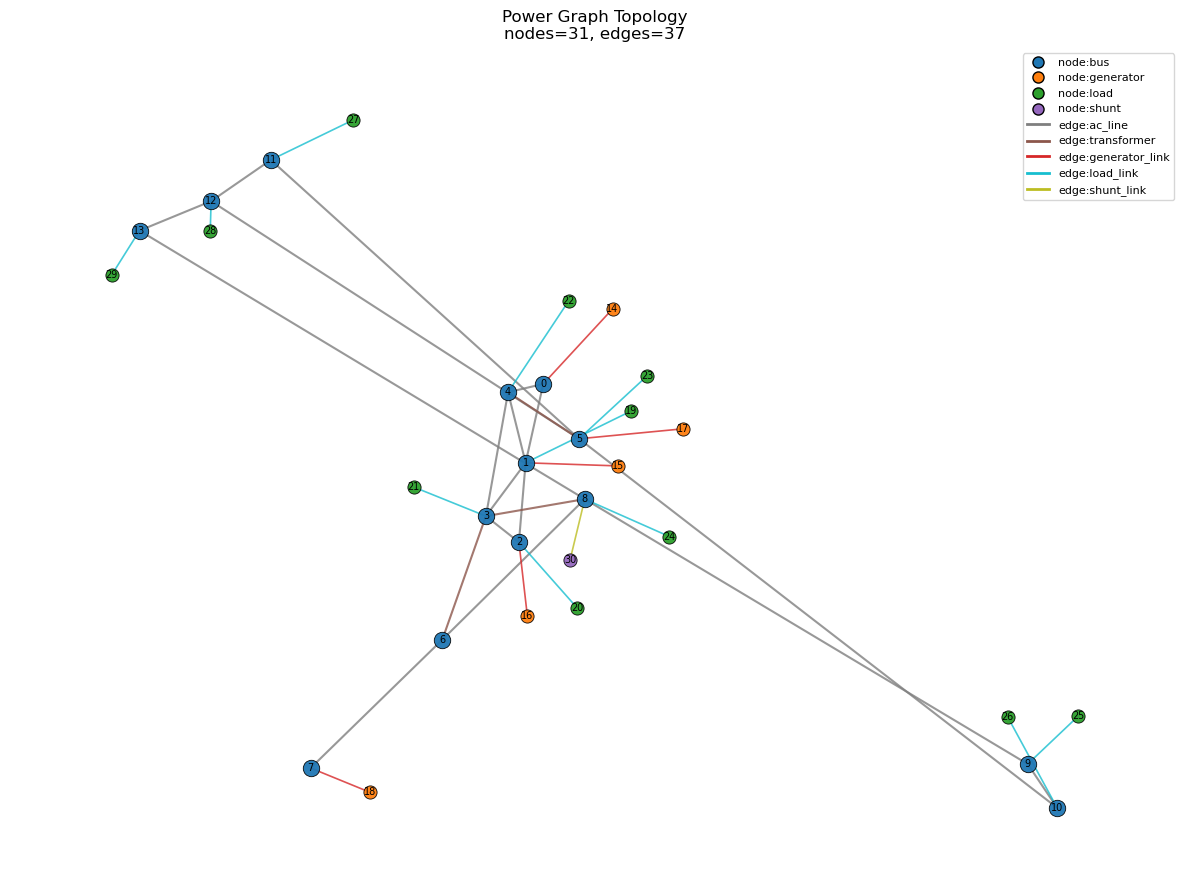

In [13]:
import math
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

# Reuse variables from previous cells: x, edge_index, node_type, edge_type, meta
n_nodes = len(x)
src, dst = edge_index
n_edges = len(src)

# Fallback: infer types from one-hot blocks if explicit vectors are absent
if node_type is None:
    node_type = [row[NODE_RAW_MAX:].index(max(row[NODE_RAW_MAX:])) for row in x]
if edge_type is None:
    edge_type = [row[EDGE_RAW_MAX:].index(max(row[EDGE_RAW_MAX:])) for row in edge_attr]

# Build graph
G = nx.DiGraph()
for i in range(n_nodes):
    G.add_node(i, t=node_type[i])
for i in range(n_edges):
    G.add_edge(int(src[i]), int(dst[i]), t=edge_type[i])

# Type maps
node_type_names = {0: "bus", 1: "generator", 2: "load", 3: "shunt"}
edge_type_names = {
    0: "ac_line",
    1: "transformer",
    2: "generator_link",
    3: "load_link",
    4: "shunt_link",
}

node_colors = {
    0: "#1f77b4",  # bus
    1: "#ff7f0e",  # generator
    2: "#2ca02c",  # load
    3: "#9467bd",  # shunt
}
edge_colors = {
    0: "#7f7f7f",  # ac_line
    1: "#8c564b",  # transformer
    2: "#d62728",  # generator_link
    3: "#17becf",  # load_link
    4: "#bcbd22",  # shunt_link
}

# Layout
k = 1.2 / max(1, math.sqrt(n_nodes))
pos = nx.spring_layout(G, seed=42, k=k)

plt.figure(figsize=(12, 9))

# Draw edges by type
for et in sorted(edge_type_names):
    e_list = [(u, v) for u, v, d in G.edges(data=True) if d["t"] == et]
    if not e_list:
        continue
    nx.draw_networkx_edges(
        G, pos,
        edgelist=e_list,
        edge_color=edge_colors[et],
        width=1.5 if et <= 1 else 1.2,
        alpha=0.8,
        arrows=False  # set True if you want direction visible
    )

# Draw nodes by type
for nt in sorted(node_type_names):
    n_list = [n for n, d in G.nodes(data=True) if d["t"] == nt]
    if not n_list:
        continue
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=n_list,
        node_color=node_colors[nt],
        node_size=140 if nt == 0 else 90,
        alpha=0.95,
        linewidths=0.6,
        edgecolors="black",
    )

# Optional labels for small graph
if n_nodes <= 80:
    nx.draw_networkx_labels(G, pos, font_size=7)

# Legend
node_legend = [
    Line2D([0], [0], marker="o", color="w", label=f"node:{node_type_names[t]}",
           markerfacecolor=node_colors[t], markeredgecolor="black", markersize=8)
    for t in sorted(node_type_names)
]
edge_legend = [
    Line2D([0], [0], color=edge_colors[t], lw=2, label=f"edge:{edge_type_names[t]}")
    for t in sorted(edge_type_names)
]
plt.legend(handles=node_legend + edge_legend, loc="best", fontsize=8)

plt.title(
    f"Power Graph Topology\n"
    f"nodes={meta.get('n_nodes', n_nodes)}, edges={meta.get('n_edges', n_edges)}"
)
plt.axis("off")
plt.tight_layout()
plt.show()

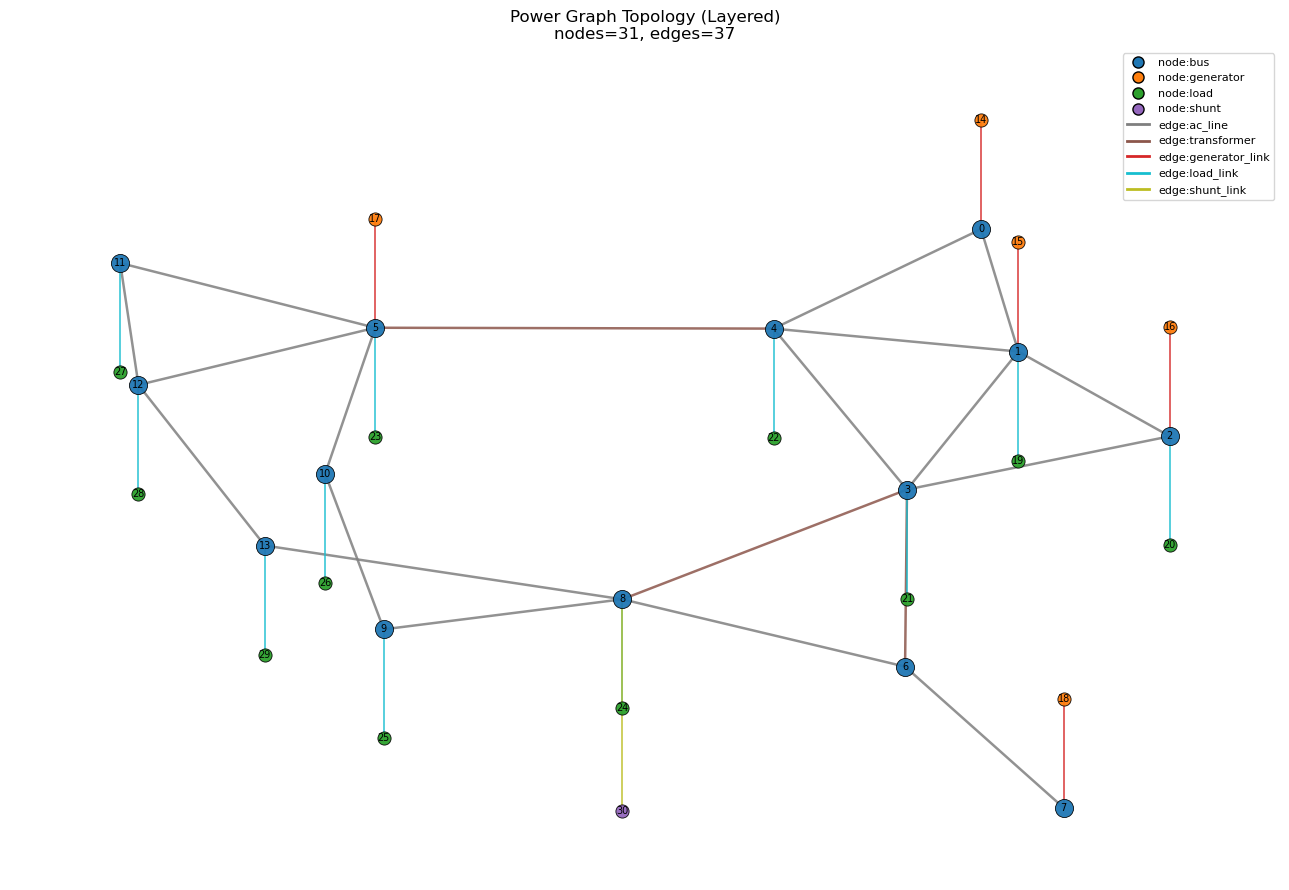

In [14]:
import math
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

# Reuse variables from previous cells: x, edge_index, edge_attr, node_type, edge_type, meta
n_nodes = len(x)
src, dst = edge_index
n_edges = len(src)

# Fallback: infer types from one-hot blocks if explicit vectors are absent
if node_type is None:
    node_type = [row[NODE_RAW_MAX:].index(max(row[NODE_RAW_MAX:])) for row in x]
if edge_type is None:
    edge_type = [row[EDGE_RAW_MAX:].index(max(row[EDGE_RAW_MAX:])) for row in edge_attr]

# Build full directed graph
G = nx.DiGraph()
for i in range(n_nodes):
    G.add_node(i, t=node_type[i])
for i in range(n_edges):
    G.add_edge(int(src[i]), int(dst[i]), t=edge_type[i])

# Type maps
node_type_names = {0: "bus", 1: "generator", 2: "load", 3: "shunt"}
edge_type_names = {
    0: "ac_line",
    1: "transformer",
    2: "generator_link",
    3: "load_link",
    4: "shunt_link",
}

node_colors = {0: "#1f77b4", 1: "#ff7f0e", 2: "#2ca02c", 3: "#9467bd"}
edge_colors = {0: "#7f7f7f", 1: "#8c564b", 2: "#d62728", 3: "#17becf", 4: "#bcbd22"}

# -------------------------
# 1) Build bus backbone layout
# -------------------------
bus_nodes = [n for n, t in enumerate(node_type) if t == 0]

bus_graph = nx.Graph()
bus_graph.add_nodes_from(bus_nodes)

for u, v, d in G.edges(data=True):
    if d["t"] in (0, 1) and node_type[u] == 0 and node_type[v] == 0:
        bus_graph.add_edge(u, v)

if len(bus_nodes) <= 1:
    bus_pos = {bus_nodes[0]: (0.0, 0.0)} if bus_nodes else {}
else:
    # keep bus topology visually meaningful
    bus_pos = nx.spring_layout(bus_graph, seed=42, k=1.2 / math.sqrt(max(1, len(bus_nodes))))

# -------------------------
# 2) Map component nodes to parent bus via link edges
# -------------------------
parent_bus = {}  # node -> bus

for u, v, d in G.edges(data=True):
    et = d["t"]
    # generator_link: generator -> bus
    if et == 2 and node_type[u] == 1 and node_type[v] == 0:
        parent_bus[u] = v
    # load_link: load -> bus
    if et == 3 and node_type[u] == 2 and node_type[v] == 0:
        parent_bus[u] = v
    # shunt_link: shunt -> bus
    if et == 4 and node_type[u] == 3 and node_type[v] == 0:
        parent_bus[u] = v

# Group by bus for layered placement
gens_by_bus = defaultdict(list)
loads_by_bus = defaultdict(list)
shunts_by_bus = defaultdict(list)

for n, t in enumerate(node_type):
    if t == 1 and n in parent_bus:
        gens_by_bus[parent_bus[n]].append(n)
    elif t == 2 and n in parent_bus:
        loads_by_bus[parent_bus[n]].append(n)
    elif t == 3 and n in parent_bus:
        shunts_by_bus[parent_bus[n]].append(n)

# -------------------------
# 3) Compose layered positions
# -------------------------
pos = dict(bus_pos)


def place_row(nodes, bx, by, y_offset, dx=0.10):
    m = len(nodes)
    for j, n in enumerate(nodes):
        x_offset = (j - (m - 1) / 2.0) * dx
        pos[n] = (bx + x_offset, by + y_offset)


# Layer offsets relative to bus
GEN_Y = +0.32
LOAD_Y = -0.32
SHUNT_Y = -0.62

for b in bus_nodes:
    bx, by = bus_pos.get(b, (0.0, 0.0))
    place_row(gens_by_bus[b], bx, by, GEN_Y, dx=0.10)
    place_row(loads_by_bus[b], bx, by, LOAD_Y, dx=0.10)
    place_row(shunts_by_bus[b], bx, by, SHUNT_Y, dx=0.08)

# Handle unlinked component nodes (fallback column on right side)
unplaced = [n for n in range(n_nodes) if n not in pos]
if unplaced:
    if bus_pos:
        x_max = max(p[0] for p in bus_pos.values())
    else:
        x_max = 0.0
    ux = x_max + 0.8
    for i, n in enumerate(unplaced):
        pos[n] = (ux, -0.15 * i)

# -------------------------
# 4) Draw
# -------------------------
plt.figure(figsize=(13, 9))

# draw edges by type (bus edges thicker)
for et in sorted(edge_type_names):
    e_list = [(u, v) for u, v, d in G.edges(data=True) if d["t"] == et]
    if not e_list:
        continue
    nx.draw_networkx_edges(
        G, pos,
        edgelist=e_list,
        edge_color=edge_colors[et],
        width=1.8 if et in (0, 1) else 1.2,
        alpha=0.85,
        arrows=False
    )

# draw nodes by type
for nt in sorted(node_type_names):
    n_list = [n for n, d in G.nodes(data=True) if d["t"] == nt]
    if not n_list:
        continue
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=n_list,
        node_color=node_colors[nt],
        node_size=170 if nt == 0 else 90,
        alpha=0.95,
        linewidths=0.6,
        edgecolors="black",
    )

if n_nodes <= 80:
    nx.draw_networkx_labels(G, pos, font_size=7)

node_legend = [
    Line2D([0], [0], marker="o", color="w", label=f"node:{node_type_names[t]}",
           markerfacecolor=node_colors[t], markeredgecolor="black", markersize=8)
    for t in sorted(node_type_names)
]
edge_legend = [
    Line2D([0], [0], color=edge_colors[t], lw=2, label=f"edge:{edge_type_names[t]}")
    for t in sorted(edge_type_names)
]
plt.legend(handles=node_legend + edge_legend, loc="best", fontsize=8)

plt.title(
    "Power Graph Topology (Layered)\n"
    f"nodes={meta.get('n_nodes', n_nodes)}, edges={meta.get('n_edges', n_edges)}"
)
plt.axis("off")
plt.tight_layout()
plt.show()